# Linear Regression

**Linear regression** is the same single-neuron model as the perceptron, with two parts that are different. Instead of a sign activation that outputs a **class label** (+1 or -1, representing which category the input belongs to), it uses a **linear activation** that outputs a real number, and instead of counting misclassifications it minimizes the **mean squared error**. We train it the same way: stochastic gradient descent, nudging the weights downhill one example at a time.

**Net input:** $z = \mathbf{w} \cdot \mathbf{x} + b$

**Activation (linear):** $\hat{y} = z$, the activation just passes the net input through unchanged.

**Cost (mean squared error):** $C(\mathbf{w}, b) = \frac{1}{2N}\sum_{i=1}^{N}(\hat{y}^{(i)} - y^{(i)})^2$

**Update rule:** $w_i \leftarrow w_i - \alpha(\hat{y} - y)x_i,\quad b \leftarrow b - \alpha(\hat{y} - y)$

| Symbol | Meaning |
|--------|---------|
| $\mathbf{x}$ | input feature(s) — here, a patient's BMI |
| $\mathbf{w}$ | learned weight(s) — one per feature |
| $b$ | bias — lets the line shift off the origin |
| $z$ | net input (here it equals the prediction, since the activation is linear) |
| $\hat{y}$ | predicted value |
| $y$ | true target value |
| $\alpha$ | learning rate (same role as $\eta$ in the perceptron) |
| $N$ | number of training examples |

**This notebook** uses the [diabetes dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) of 442 patients, predicting **disease progression** one year after baseline from a single feature, **body mass index (BMI)**. Unlike the perceptron's perfectly separable penguins, this is real, noisy clinical data, so the goal isn't a perfect fit but the best straight line through the trend.

## Imports and Setup

We need NumPy for the math, matplotlib for plotting, and the diabetes dataset and a train/test splitter from scikit-learn. (Seaborn is only for nicer styling.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

sns.set_theme()  # nicer default plot styling

In [2]:
# Load the diabetes dataset from the shared Datasets folder.
# The "../" steps out of this algorithm folder and into Supervised-Learning/Datasets.
# df = pd.read_csv("../Datasets/diabetes.csv")

# If you don't have the CSV locally, you can load it straight from scikit-learn instead:
# scaled=False gives the original clinical units (real BMI values), not the pre-normalized version.
data = load_diabetes(scaled=False, as_frame=True)
df = data.frame

# Preview the first 5 rows to confirm the data loaded correctly and see the column names.
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


## The Data

The diabetes dataset records ten baseline measurements for 442 patients, along with a **disease progression score** measured one year later (column labeled target). We'll use just one feature, **BMI**, to keep this a single-variable regression we can draw as a line.

We already saw (when picking this dataset) that BMI has the strongest linear relationship with progression, so it's the natural single predictor.

In [3]:
# Pull out our single feature (BMI) and the target (disease progression).
X = df["bmi"].values.reshape(-1, 1)   # reshape to a column: SGD expects a 2D feature matrix
y = df["target"].values

print(f"Patients: {len(y)}")
print(f"BMI range:    {X.min():.1f} to {X.max():.1f}")
print(f"Target range: {y.min():.0f} to {y.max():.0f}  (disease progression score)")

Patients: 442
BMI range:    18.0 to 42.2
Target range: 25 to 346  (disease progression score)


### Is the relationship actually linear?

Just like with the perceptron, we look before we model. If higher BMI tends to go with higher disease progression in a roughly straight-line way, linear regression is the right tool.

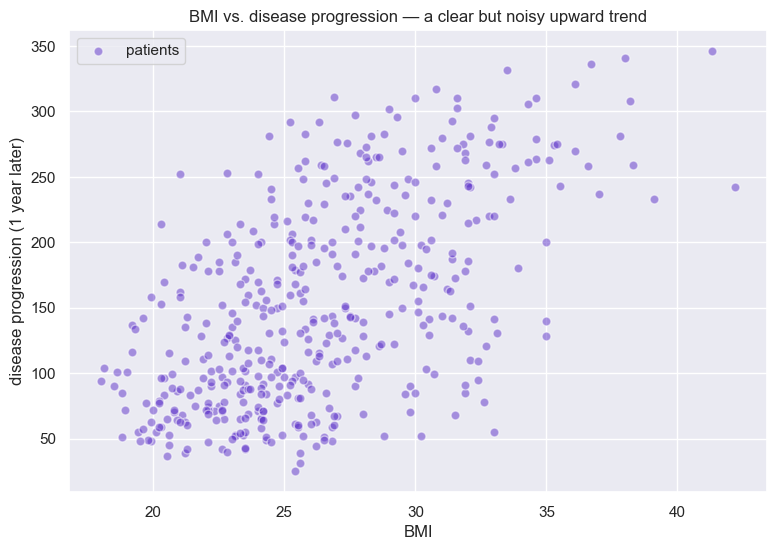

In [4]:
plt.figure(figsize=(9, 6))
plt.scatter(X, y, color="#5d32ca", alpha=0.5, edgecolors="white", s=40, label="patients")
plt.xlabel("BMI")
plt.ylabel("disease progression (1 year later)")
plt.title("BMI vs. disease progression — a clear but noisy upward trend")
plt.legend()
plt.show()

### Preparing the data: split and standardize

Two steps before training:

1. **Train/test split.** We randomly split the 442 patients into 80% for training and 20% for testing. The model learns only from the training set; the test set is locked away and used only at the end to check if the model works on data it has never seen.

2. **Standardize the feature.** Stochastic gradient descent is sensitive to feature scale: the weight update is `w -= alpha * error * x`, so BMI values like `32` get multiplied directly into every update, causing large unstable jumps. We fix this by rescaling BMI to have mean 0 and standard deviation 1. We only standardize **BMI (X), not disease progression (y)**, the target only appears inside the error term `(ŷ - y)`, which affects all weights uniformly and can be controlled with the learning rate. Leaving y in its original units also keeps predictions interpretable. We compute the mean and standard deviation from the **training set only**, then apply them to both sets, so no information leaks from the test data.

In [5]:
# Hold out 20% of patients as a test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Standardize BMI using TRAIN statistics only (mean 0, std 1).
mean, standard_deviation = X_train.mean(), X_train.std()
X_train_s = (X_train - mean) / standard_deviation
X_test_s  = (X_test - mean) / standard_deviation

print(f"Training patients: {len(y_train)} | Test patients: {len(y_test)}")
print(f"Standardized BMI mean: {X_train_s.mean():.2f}, std: {X_train_s.std():.2f}")

Training patients: 353 | Test patients: 89
Standardized BMI mean: -0.00, std: 1.00


## The Cost Function and Its Gradient

We measure how wrong the model is using **mean squared error (MSE)**. There are two versions, and it's important to know which one is doing what:

**Full batch cost** — averages the squared error over all N patients. This is what we track after each epoch to watch convergence:

$$C(\mathbf{w}, b) = \frac{1}{2N}\sum_{i=1}^{N}(\hat{y}^{(i)} - y^{(i)})^2$$

**Per-example cost** — the same formula but for a single patient $i$. This is what stochastic gradient descent actually differentiates to compute each weight update:

$$C^{(i)}(\mathbf{w}, b) = \frac{1}{2}(\hat{y}^{(i)} - y^{(i)})^2$$

The $\frac{1}{2}$ cancels cleanly with the exponent when you take the derivative, giving a simple gradient for a single example:

$$\frac{\partial C^{(i)}}{\partial w} = (\hat{y}^{(i)} - y^{(i)})\,x^{(i)}, \qquad \frac{\partial C^{(i)}}{\partial b} = (\hat{y}^{(i)} - y^{(i)})$$

So in each training step, stochastic gradient descent picks one patient, computes their error $(\hat{y} - y)$, and nudges the weights down that single patient's gradient, instead of summing over all 353 patients before moving. The full batch cost is only computed at the end of each epoch for logging purposes.

## Implementing the Model

### What changed from the perceptron

The class is almost identical to the perceptron. Only two lines really differ:

- **`predict`** applies a *linear* activation, which just returns the net input, instead of `np.sign`.
- **`train`** steps downhill on the MSE gradient $(\hat{y} - y)x$ and records the **MSE** each epoch (`costs_`), instead of counting misclassifications.

### The class

Same skeleton as before: `net_input` computes $\mathbf{w}\cdot\mathbf{x} + b$, `predict` applies the activation, and `train` runs stochastic gradient descent.

In [6]:
class LinearRegression:
    """A single-neuron linear regression model trained with stochastic gradient descent.

    The model learns a weight vector and bias so that w . x + b predicts a
    continuous target. The linear activation simply returns the net input.

    Parameters
    ----------
    alpha : float
        Learning rate; controls how large each weight update is.
    epochs : int
        Number of passes over the training data.

    Attributes
    ----------
    weights_ : np.ndarray, shape (n_features,)
        Learned feature weights (available after calling train).
    bias_ : float
        Learned bias term.
    costs_ : list of float
        Mean squared error per epoch, used to visualize convergence.
    """

    def __init__(self, alpha=0.01, epochs=50):
        self.alpha = alpha
        self.epochs = epochs

    def net_input(self, X):
        """Compute the weighted sum w . x + b (the pre-activation value)."""
        return np.dot(X, self.weights_) + self.bias_

    def predict(self, X):
        """Linear activation: return the net input unchanged.
        This is the one piece swapped out from the perceptron (Linear instead of sign)."""
        return self.net_input(X)

    def train(self, X, y):
        """Learn weights and bias by minimizing MSE with stochastic gradient descent."""
        # One small random weight per feature, plus a zero bias to start.
        self.weights_ = np.random.randn(X.shape[1]) * 0.01
        self.bias_ = 0.0
        self.costs_ = []
        N = X.shape[0]

        for _ in range(self.epochs):
            # Stochastic gradient descent: update from one patient at a time.
            for xi, target in zip(X, y):
                # Gradient of the per-example MSE (1/2)(y_hat - y)^2:
                #   dC/dw = (y_hat - y) * x ,  dC/db = (y_hat - y)
                error = self.predict(xi) - target
                # Step downhill: w <- w - alpha * gradient
                self.weights_ -= self.alpha * error * xi
                self.bias_    -= self.alpha * error
            # Record the mean squared error over ALL training data this epoch.
            self.costs_.append((1 / (2 * N)) * np.sum((self.predict(X) - y) ** 2))
        return self

## Training the Model

We create the model, pick a learning rate and number of epochs, and train on the standardized BMI. A small learning rate keeps the updates stable.

In [7]:
np.random.seed(1)
model = LinearRegression(alpha=0.001, epochs=500)
model.train(X_train_s, y_train)

print(f"Learned weight: {model.weights_[0]:.1f}")
print(f"Learned bias:   {model.bias_:.1f}")
print(f"Final training MSE: {model.costs_[-1]:.1f}")

Learned weight: 47.4
Learned bias:   153.7
Final training MSE: 1934.1


## The Fitted Line

To draw the line, we create 100 evenly spaced real BMI values across the data range, standardize them so the model can use them, and collect the 100 predicted progression scores. `plt.plot` then connects those 100 (real BMI, predicted progression) pairs into the visible line, so the x-axis shows interpretable BMI values while the predictions are computed from the standardized versions behind the scenes.

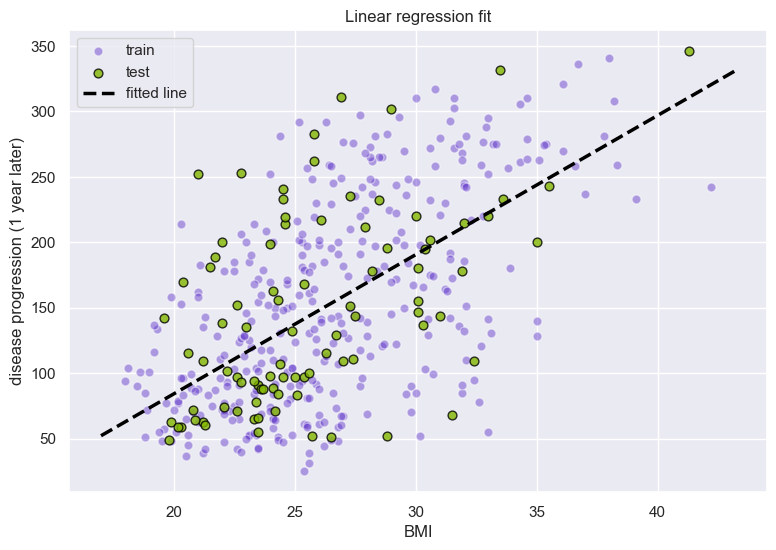

In [8]:
# A smooth range of real BMI values to draw the line over.
bmi_domain = np.linspace(X.min() - 1, X.max() + 1, 100).reshape(-1, 1)
bmi_domain_s = (bmi_domain - mean) / standard_deviation   # standardize the same way as training
line = model.predict(bmi_domain_s)

plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, color="#5d32ca", alpha=0.45, edgecolors="white", s=40, label="train")
# Test points in green, never seen during training, but they still follow the line relatively closely.
plt.scatter(X_test,  y_test,  color="#82b600", alpha=0.8,  edgecolors="black", s=40, label="test")
# Each real BMI in bmi_domain and its standardized counterpart in bmi_domain_s represent the same point,
# so the prediction maps back to the correct x position — real BMI on the axis, model output as y.
plt.plot(bmi_domain, line, color="black", lw=2.5, linestyle="dashed", label="fitted line")
plt.xlabel("BMI")
plt.ylabel("disease progression (1 year later)")
plt.title("Linear regression fit")
plt.legend()
plt.show()

## Evaluating with RMSE

MSE is in *squared* (disease progression) units, which is hard to interpret. Taking its square root gives the **root mean squared error (RMSE)**, which is back in the original units.

RMSE is *not* the average error, it's the square root of the average of **squared** errors. Because errors are squared before averaging, larger misses are penalized more heavily than smaller ones. An RMSE of ~60 means: if you squared every individual prediction error, averaged those squares, and took the square root, you get 60. It's a measure of typical error magnitude that is pulled upward by large outliers more than a simple average would be. (The plain average of absolute errors, MAE, would generally be a smaller number for the same predictions.) That said, RMSE is still a practical way to translate MSE into something interpretable in the dataset's own units, a single number you can compare directly against the scale of the target.

We check it on both the training set and the held-out test set. Similar values mean the model generalizes rather than memorizes.

In [9]:
def rmse(y_true, y_pred):
    """Root mean squared error: typical prediction error in the target's own units."""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

train_rmse = rmse(y_train, model.predict(X_train_s))
test_rmse  = rmse(y_test,  model.predict(X_test_s))

print(f"Train RMSE: {train_rmse:.1f}")
print(f"Test RMSE:  {test_rmse:.1f}")

Train RMSE: 62.2
Test RMSE:  63.2


## How the Error Decreased

Because we stored the MSE each epoch in `costs_`, we can watch training happen. Here's the key contrast with the perceptron: the perceptron's errors dropped all the way to **zero** because its data was perfectly separable. Here the MSE falls quickly and then **levels off at a nonzero value**. That floor is irreducible noise which is scatter no straight line can ever remove. Reaching it means the model found the best line it can, not that it failed.

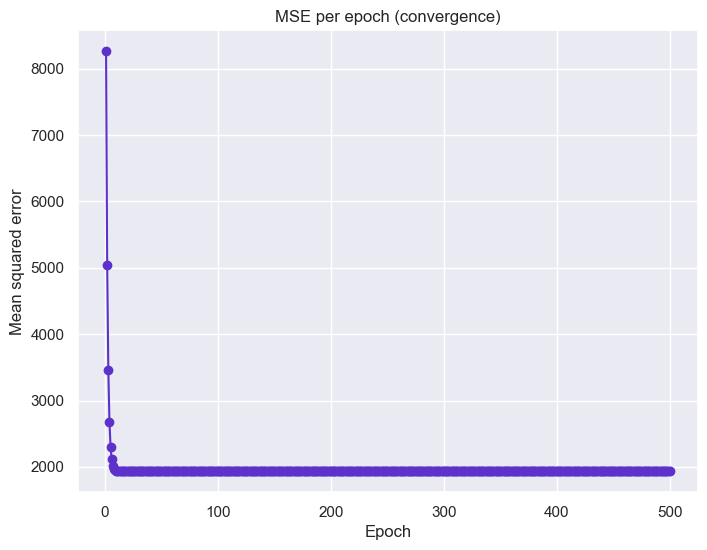

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(model.costs_) + 1), model.costs_, marker="o", color="#5d32ca")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("MSE per epoch (convergence)")
plt.show()

## Experimenting with the Learning Rate

The learning rate $\alpha$ is the most important knob in gradient descent. Too small and learning crawls; too large and the updates overshoot and bounce around the minimum. Here we fit the model with a few different values and compare the resulting lines.

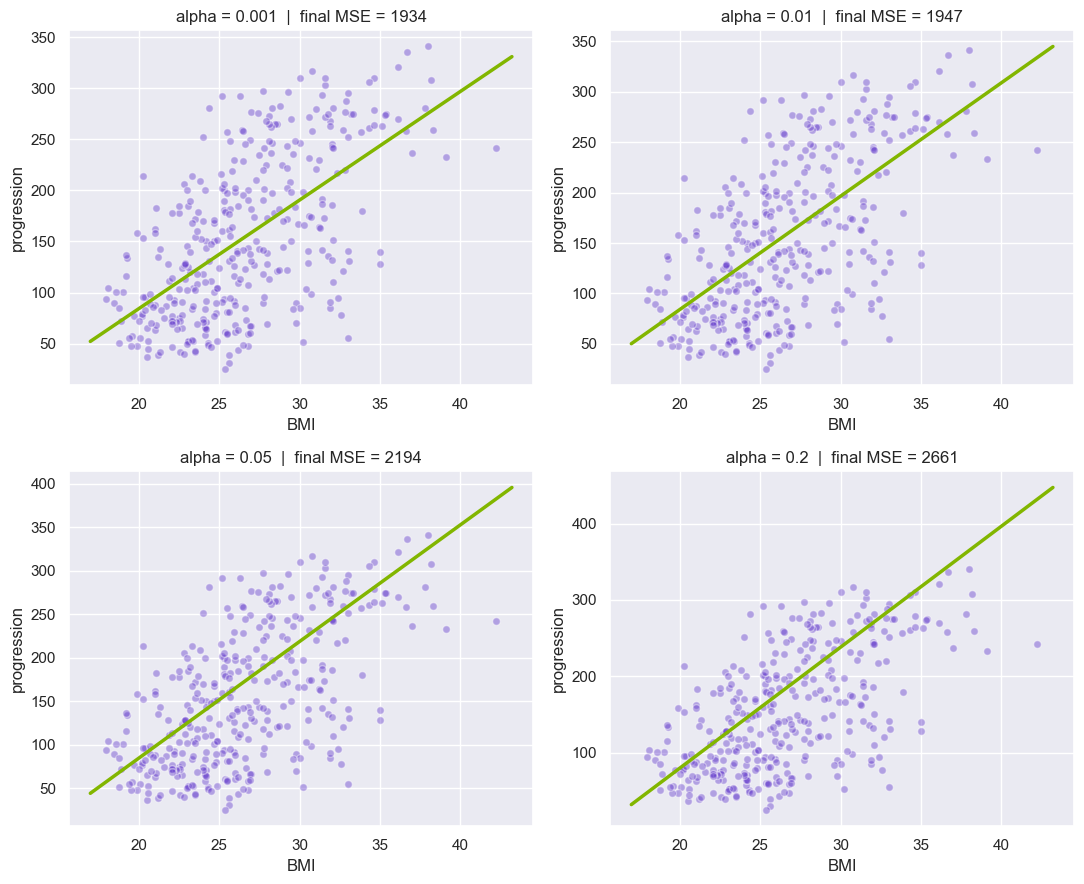

In [11]:
alphas = [0.001, 0.01, 0.05, 0.2]
fig, axs = plt.subplots(2, 2, figsize=(11, 9))

for ax, a in zip(axs.flat, alphas):
    np.random.seed(1)
    m = LinearRegression(alpha=a, epochs=50).train(X_train_s, y_train)
    ax.scatter(X_train, y_train, color="#5d32ca", alpha=0.4, edgecolors="white", s=30)
    ax.plot(bmi_domain, m.predict(bmi_domain_s), color="#82b600", lw=2.5)
    ax.set_title(f"alpha = {a}  |  final MSE = {m.costs_[-1]:.0f}", fontsize=12)
    ax.set_xlabel("BMI"); ax.set_ylabel("progression")
plt.tight_layout()
plt.show()

## Conclusion

Our single-neuron linear regression learned the best straight line through the BMI–progression data, with a test RMSE close to its training RMSE, so it generalizes to unseen patients. Additionally, it reused the *entire* perceptron machine: the same net input, the same stochastic gradient descent loop, the same `predict`/`train` structure. We only swapped the **sign activation for a linear one** and the **misclassification count for the mean squared error**, then derived the matching gradient.

The MSE leveling off above zero is a good takeaway of regression as real clinical data is noisy, and a single feature (BMI) can only explain part of disease progression. The remaining error is the signal that we'd need *more features* to do better. That naturally points toward **multiple linear regression**, and toward the next models in this repository that handle relationships with more variables than 2 at play.